In [1]:
%load_ext autoreload
%autoreload 2

import sys

PROJECT = "/Users/Guille/Desktop/dynamic_update/functional_forecast_dynamic_update"

sys.path.insert(0, PROJECT)

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from skfda import FDataGrid
from skfda.exploratory.depth import IntegratedDepth, ModifiedBandDepth

from matplotlib_scalebar.scalebar import ScaleBar

from src import loader, plotter

from src.config import DATA, DEPTH, IMAGES, VALIDATION, TABLES
from src.fda import _fDepth, _fQuantile
from src.utils import KS, get_band_fraction, get_hyper, mask_intervals

from src.fdu import functional_dynamic_update

# Loading color palette
palette_ = pd.read_csv(DATA / "palette.csv")

# Loading Texas map
_TX = gpd.read_file(DATA / "maps/TX/State.shp")

T = 288
method = "fusion"
resource = "wind"
aggregation = "asset"

# Update seasonal and spatial distance with similarity metric and lambda parameters
# kappa_0 to the code first neighborhood threshold
# Remove xi and gamma

# Load Data

In [2]:
(
    F_tr_,
    F_ts_,
    E_tr_,
    E_ts_,
    X_tr_,
    X_ts_,
    T_tr_,
    T_ts_,
    assets_tr_,
    assets_ts_,
    t_tr_,
    t_ts_,
    dt_,
    dx_,
) = loader.preprocessed_dataset(
    unbiased = True,
    path_to_training_data = DATA / "preprocessed_wind_2017.pkl",
    path_to_testing_data = DATA / "preprocessed_wind_2018.pkl",
    T = 288,
)

print(F_tr_.shape, F_ts_.shape)
print(E_tr_.shape, E_ts_.shape)
print(X_tr_.shape, X_ts_.shape)
print(T_tr_.shape, T_ts_.shape)
print(assets_tr_.shape, assets_ts_.shape)
print(t_tr_.shape, t_ts_.shape)
print(dt_.shape, dx_.shape)

E_tr_lin_, E_ts_lin_ = loader.processed_dataset(
    unbiased = True,
    path_to_training_data = DATA / "linear_preprocessed_wind_2017.pkl",
    path_to_testing_data = DATA / "linear_preprocessed_wind_2018.pkl",
    T = 288,
)

print(E_tr_lin_.shape, E_ts_lin_.shape)

E_tr_biased_, E_ts_biased_ = loader.processed_dataset(
    unbiased = False,
    path_to_training_data = DATA / "preprocessed_wind_2017.pkl",
    path_to_testing_data = DATA / "preprocessed_wind_2018.pkl",
    T = 288,
)

print(E_tr_biased_.shape, E_ts_biased_.shape)

(67881, 288) (364, 288, 187)
(67881, 288) (364, 288, 187)
(67881, 2) (187, 2)
(67881, 288) (364, 288)
(67881, 1) (187,)
(67881,) (364,)
(288,) (288,)
(67881, 288) (364, 288, 187)
(67881, 288) (364, 288, 187)


In [430]:
# wind unbiased-025 {72: 1, 144: 4, 216: 1}
# wind biased-025 {72: 2, 144: 1, 216: 2}
exp_description="unbiased-025-1"
_init = {72: 1, 144: 2, 216: 1}

exp_description="unbiased-025-2"
_init = {72: 1, 144: 3, 216: 3}

exp_description="unbiased-025-3"
_init = {72: 1, 144: 2, 216: 2}

exp_description="unbiased-025-6"
_init = {72: 3, 144: 4, 216: 1}

# exp_description="biased-025"
# _init = {72: 5, 144: 2, 216: 1}

hyper_, envelope_ = loader.hyperparameters(
    _init,
    resource,
    method,
    aggregation,
    exp_description,
    path_to_validation = VALIDATION,
)

hyper_.loc['length_scale_f'] = 1./hyper_.loc['tau']
hyper_.loc['length_scale_e'] = hyper_.loc['length_scale_f']*hyper_.loc['rho_e']
hyper_.loc['length_scale_d'] = hyper_.loc['length_scale_f']*hyper_.loc['rho_d']
print(hyper_)
# print(envelope_)

stats_, funcs_ = loader.get_asset_stats(
    _init, 
    resource, 
    method, 
    aggregation, 
    exp_description, 
    T, 
    VALIDATION, 
)
# print(stats_)
# print(funcs_)

time                   72           144          216
p_fusion          0.750000     0.750000     0.750000
forget_rate_f     0.125000     0.125000     0.125000
forget_rate_e     1.000000     1.000000     1.000000
lookahead_rate    4.000000     4.000000     4.000000
tau               0.010000     0.010000     0.010000
kappa           150.000000   150.000000   150.000000
rho_e             0.604503     0.193503     0.412193
rho_d             0.082507     0.014069     0.000643
kappa_0         150.000000  2166.000000  2282.000000
nu                6.000000     5.000000     9.000000
sigma             0.188068     0.157037     0.121467
length_scale_f  100.000000   100.000000   100.000000
length_scale_e   60.450323    19.350282    41.219254
length_scale_d    8.250743     1.406934     0.064285


In [433]:
df_fmt, latex = loader.error_scores(
    _init,
    resource, 
    method,
    aggregation,
    exp_description,
    VALIDATION,
)
print(latex)

# df_fmt, latex = loader.envelope_scores(
#     envelope_, 
#     alphas = (0.1, 0.2),
# )
# print(df_fmt)

df_fmt, latex = loader.envelope_scores(
    envelope_, 
    alphas = [0.1, 0.2],
)
print(latex)

\begin{table}
\caption{Forecast error metrics by lead time and distance method.}
\label{tab:error_metrics}
\begin{tabular}{clccc}
\toprule
 &  & RMSE & MAE & MBE \\
Forecast Update Time $\tau$ & Estimator &  &  &  \\
\midrule
\multirow[c]{3}{*}{72} & nan & 0.1313 & 0.0988 & 0.0021 \\
 & $\hat{\mu}_{deep}(s)$ & 0.1419 & 0.1067 & 0.0027 \\
 & $\hat{\mu}_{focal}(s)$ & 0.1312 & 0.1017 & -0.0033 \\
\multirow[c]{3}{*}{144} & nan & 0.1473 & 0.1130 & -0.0027 \\
 & $\hat{\mu}_{deep}(s)$ & 0.1653 & 0.1275 & -0.0034 \\
 & $\hat{\mu}_{focal}(s)$ & 0.1496 & 0.1185 & -0.0030 \\
\multirow[c]{3}{*}{216} & nan & 0.1447 & 0.1205 & -0.0093 \\
 & $\hat{\mu}_{deep}(s)$ & 0.1501 & 0.1256 & -0.0133 \\
 & $\hat{\mu}_{focal}(s)$ & 0.1436 & 0.1222 & -0.0073 \\
\bottomrule
\end{tabular}
\end{table}

\begin{tabular}{clcccccccccccccccccc}
\toprule
 &   & \multicolumn{6}{c}{FIS} & \multicolumn{6}{c}{FCS} & \multicolumn{6}{c}{SCP} \\
 &   & \multicolumn{2}{c}{MBD} & \multicolumn{2}{c}{fknn} & MBD$_{k=1-\alpha}$ & EC

In [5]:
# The same region, different day, for a given interval (eg, 144), low and high scores.
interval = 144   # or "144" if your columns are strings
df_score = stats_.copy()
df_funcs = funcs_.copy()

df_score = df_score.loc[
    ((df_funcs[interval] < 1. ) & (df_funcs[interval] > .9 ))
].reset_index(drop = True)

# Lowest score day for each region
idx_low = df_score.groupby("region")[interval].idxmin()
low_df = df_score.loc[idx_low].rename(
    columns={"day": "low_day", interval: "low_score"}
)
low_df = low_df[["region", "low_day", "low_score"]]
print(low_df.shape)

# Highest score day for each region
idx_high = df_score.groupby("region")[interval].idxmax()

high_df = df_score.loc[idx_high].rename(
    columns={"day": "high_day", interval: "high_score"}
)
high_df = high_df[["region", "high_day", "high_score"]]
print(high_df.shape)

summary = low_df.merge(high_df, on="region")
summary["difference"] = summary["high_score"] - summary["low_score"]
summary = summary.sort_values("region", ascending=False).reset_index(drop=True)
print(summary)

(10, 3)
(10, 3)
   region  low_day  low_score  high_day  high_score  difference
0      19       79   0.203555       328    0.372372    0.168817
1      18      333   0.201632       275    0.326795    0.125163
2      17      101   0.243602        84    0.287097    0.043495
3      16       95   0.226597       148    0.365050    0.138453
4      15       48   0.222506       114    0.361239    0.138733
5      14       95   0.258111       315    0.382400    0.124289
6      13       39   0.244067       238    0.360186    0.116119
7      12      344   0.213483        50    0.383629    0.170146
8      11      327   0.246825       334    0.343040    0.096215
9      10      131   0.175070       161    0.326196    0.151126


In [466]:
# The same region, same day, growing scores across intervals (72, 144, 216).
df_score = stats_.copy()
df_funcs = funcs_.copy()
intervals_ = keys = list(_init.keys())

df_score = df_score.loc[
    ((df_funcs[interval] < 1. ) & (df_funcs[interval] > .5 ))
].reset_index(drop = True)

# Strictly decreasing score
growing_df = df_score[
    ((df_score[intervals_[0]] >= df_score[intervals_[1]]) 
    & (df_score[intervals_[1]] >= df_score[intervals_[2]]))
].copy()

growing_df["increase_1"] = growing_df[intervals_[0]] - growing_df[intervals_[1]]
growing_df["increase_2"] = growing_df[intervals_[1]] - growing_df[intervals_[2]]
growing_df["increase"]   = growing_df[["increase_1", "increase_2"]].min(axis=1)

growing_df = growing_df.sort_values("increase", ascending=False).reset_index(drop=True)

print(growing_df.head(20))

    region  day        72       144       216  increase_1  increase_2  \
0       12  356  0.353560  0.248028  0.127557    0.105532    0.120471   
1       17   37  0.374367  0.276828  0.163213    0.097538    0.113615   
2       17   70  0.293178  0.198400  0.094144    0.094778    0.104256   
3       17  103  0.343640  0.257223  0.159218    0.086417    0.098005   
4       12    7  0.319295  0.236290  0.091355    0.083005    0.144936   
5       10  329  0.301722  0.204163  0.122854    0.097559    0.081310   
6       17  111  0.339633  0.214800  0.136296    0.124833    0.078504   
7       10   10  0.284123  0.207810  0.132777    0.076312    0.075034   
8       17  337  0.309802  0.198950  0.124851    0.110853    0.074099   
9       17   12  0.321992  0.215909  0.143001    0.106083    0.072908   
10      10   21  0.285709  0.212888  0.123527    0.072821    0.089361   
11      17   96  0.322313  0.251122  0.171160    0.071191    0.079962   
12      12  231  0.322201  0.240856  0.173610    0.

In [ ]:
# # Two regions, same day, low and high scores for the same interval (eg, 144).
# df_score = stats_.copy()
# interval = intervals_[0]

# # Lowest-score region for each day
# idx_low = df_score.groupby("day")[interval].idxmin()

# # Highest-score region for each day
# idx_high = df_score.groupby("day")[interval].idxmax()

# low_df = df_score.loc[idx_low].rename(columns={"region": "low_region", interval: "low_score"})
# low_df = low_df[["day", "low_region", "low_score"]]

# high_df = df_score.loc[idx_high].rename(columns={"region": "high_region", interval: "high_score"})
# high_df = high_df[["day", "high_region", "high_score"]]

# summary = low_df.merge(high_df, on="day")
# summary["difference"] = summary["high_score"] - summary["low_score"]
# summary = summary.sort_values("difference", ascending=False).reset_index(drop=True)
# print(summary)

# Functional kNNs dynamic update

Barton Chapel Wind Farm 2018-01-08 12:00:00
0.06656209946843865 123.49429367267136
wind-12-7-144-asset


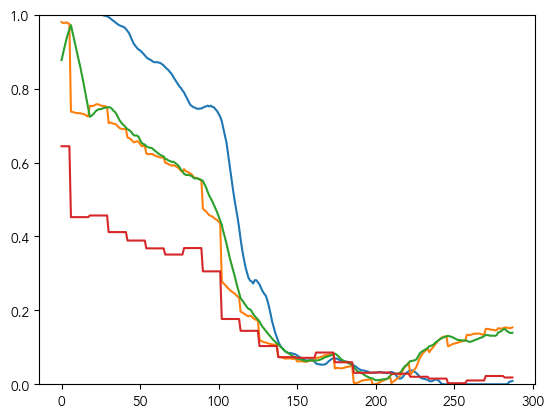

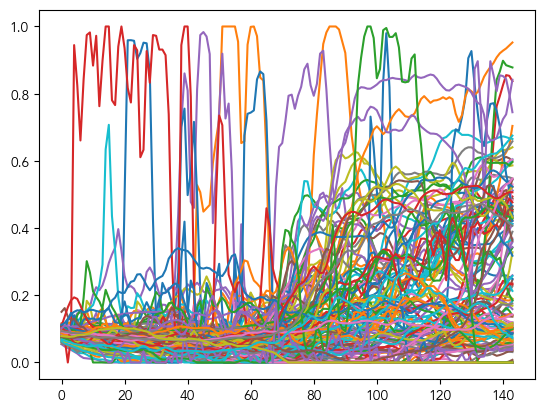

In [472]:
# Blue Summit 2018-01-06 12:00:00
# [0 1 2] [ 165 1838   16] 0.32089993194505706
# (2019,) (67881,) (2019,) (150,)
# Blanco Canyon 18 112 in 176
# Black Jack Creek Wind 17 289

day = 7
asset = 12              
interval = 144

_fdu = functional_dynamic_update(
    _distances = {"temporal": "seasonal_equinox", 
                  "spatial": "haversine", 
                  "fusion": "dynamic"},
    name = assets_ts_[asset],
    date = T_ts_[day, interval],
)
print(_fdu.name, _fdu.date)

# Filter solar hours with loading solar set
interval_mask = mask_intervals(
    F_tr_, 
    E_tr_biased_, 
    t_tr_, 
    day, 
    day_window = 7,
)
n_mask = interval_mask.sum()
_fdu.fit(
    F_tr_,
    E_tr_lin_,
    dt_,
    X_ = X_tr_,
    t_ = t_tr_,
    interval_mask = interval_mask,
    n_samples_per_hour = 12,
)
M_ = _fdu.predict(
    F_ts_[day, :interval, asset], 
    E_ts_lin_[day, :, asset], 
    X_ts_[asset, :], 
    t_ts_[day],
    forget_rate_f = get_hyper(hyper_, "forget_rate_f", interval),
    forget_rate_e = get_hyper(hyper_, "forget_rate_e", interval),
    lookahead_rate = get_hyper(hyper_, "lookahead_rate", interval),
    length_scale_f = get_hyper(hyper_, "length_scale_f", interval),
    length_scale_e = get_hyper(hyper_, "length_scale_e", interval),
    length_scale_d = get_hyper(hyper_, "length_scale_d", interval),
    sigma = get_hyper(hyper_, "sigma", interval),
    nu = get_hyper(hyper_, "nu", interval),
    kappa_0 = get_hyper(hyper_, "kappa_0", interval),
    kappa = get_hyper(hyper_, "kappa", interval),
    p_fusion = get_hyper(hyper_, "p_fusion", interval),
)

print(_fdu.xi, _fdu.ess)

# Plotting variables
e_biased_ = E_ts_biased_[day, :, asset]
f_hat_ = F_ts_[day, interval:, asset]
e_lin_ = E_ts_lin_[day, :, asset]
x_ts_ = X_ts_[asset, :]
e_ = E_ts_[day, :, asset]
f_ = F_ts_[day, :interval, asset]

file_name = f"{resource}-{asset}-{day}-{interval}-asset"
print(file_name)

plt.figure()
plt.plot(F_ts_[day, :, asset])
plt.plot(e_)
plt.plot(e_lin_)
plt.plot(e_biased_)
plt.ylim(0, 1)
plt.show()

plt.figure()
plt.plot(M_.T)
plt.show()

In [ ]:
# # Samples in each confidence band
# score = 'FCS'
# distance = "fknn"
# alpha_ = [0.1, 0.2, 0.3, 0.4]
# _depth = ModifiedBandDepth()

# M_int_, M_int_ds_ = _fdu.functional_downsampling(
#     subsample=12, 
#     n_basis=int(1.333*(T - interval)/12),
# )

# k_ = get_band_fraction(
#     envelope_, 
#     alpha_, 
#     interval, 
#     distance, 
#     score,
# )

# J_ = _fdu.focal_curve_envelope(
#     None, 
#     _fdu.M_int_, 
#     distance,
# )

# J_hat_ = _fdu.focal_curve_envelope(
#     None,
#     _fdu.M_ext_,
#     distance,
#     max_iter = 100,
# )

# # no k_: the band is the min/max over all of J_
# f_focal_, _upper_focal, _lower_focal = _fdu.focal_envelope_confidence_region(
#     alpha_,
#     k_prj_,
# )

# for alpha in alpha_:
#     FIS_focal = _interval_score(f_hat_, _lower_focal[f'{alpha}'][1:], _upper_focal[f'{alpha}'][1:], alpha).mean()
#     FCS_focal = _coverage_score(f_hat_, _lower_focal[f'{alpha}'][1:], _upper_focal[f'{alpha}'][1:])
#     SCP_focal = _simultaneous_coverage(f_hat_, _lower_focal[f'{alpha}'][1:], _upper_focal[f'{alpha}'][1:])

#     results_.append([time, region, day, alpha, fraction, distance, FIS_focal, FCS_focal, SCP_focal])


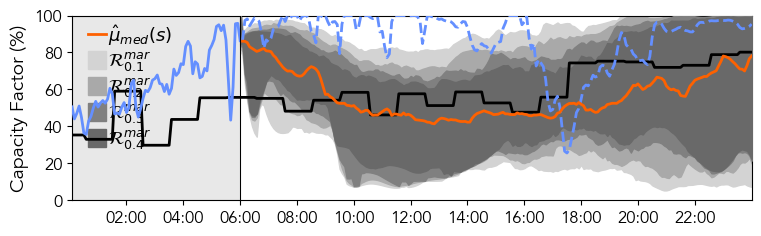

In [465]:
# Calculate confidence intervals from Directional Quantiles
alpha_ = [0.1, 0.2, 0.3, 0.4]
M_int_, M_int_ds_ = _fdu.functional_downsampling(
    subsample=12, 
    n_basis=int(1.333*(T - interval)/12),
)

f_median_ext_, _upper, _lower = _fdu.ecdf_confidence_bands(
    M_int_, 
    alpha_,
)

f_wmedian_ext_, _wupper, _wlower = _fdu.weighted_ecdf_confidence_region(
    M_int_, 
    _fdu.w_prime_,
    alpha_,
)

_fig, _ax = plt.subplots(
    figsize=(7.5, 2.25), 
    constrained_layout=True
)

plotter.plot_envelope(
    _fig, 
    _ax, 
    palette_,
    _wupper, 
    _wlower, 
    f_wmedian_ext_, 
    f_, 
    f_hat_, 
    e_biased_, 
    dx_,
    dt_ = dt_ + 5, 
    interval = interval,
    n = 120,
    color_med = palette_.loc[3, "ibm"],
    CR=r"$\mathcal{{R}}^{{mar}}_{{{}}}$",
    label = r"$\hat{\mu}_{med} (s)$",
    range_ = [0, 287],
    legend_1 = False,
    legend_2 = True,
)

_ax.legend(
    frameon = False,
    loc = (0.0125, .225),
    #loc = 'lower center',
    fontsize = 13,
    columnspacing = 0.25,
    handletextpad = 0.125,
    labelspacing = 0.125,
    ncol = 1,
)

plt.savefig(IMAGES / f"median_mar_regions-{file_name}.pdf")

plt.show()

(135, 144)


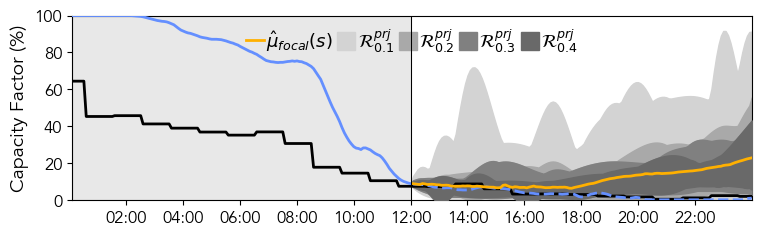

In [478]:
# Samples in each confidence band
score = 'FCS'
distance = "fknn"
alpha_ = [0.1, 0.2, 0.3, 0.4]

M_int_, M_int_ds_ = _fdu.functional_downsampling(
    subsample=12, 
    n_basis=int(1.333*(T - interval)/12),
    #n_basis=20,

)

J_ = _fdu.focal_curve_envelope(
    None, 
    M_int_, 
    dist ="l2" ,
    max_iter = 100,
)
print(J_.shape)
k_ = get_band_fraction(
    envelope_, 
    alpha_, 
    interval, 
    distance, 
    score,
)

f_focal_ext_, _upper, _lower = _fdu.focal_envelope_confidence_region(
    alpha_, 
    k_*5,
)

_fig, _ax = plt.subplots(
    figsize=(7.5, 2.25), 
    constrained_layout=True
)

plotter.plot_envelope(
    _fig, _ax, palette_,
    _upper, _lower, f_focal_ext_, f_, f_hat_, e_biased_, dx_,
    dt_ = dt_ + 5, 
    interval = interval,
    n = 120,
    color_med = palette_.loc[4, "ibm"],
    label = r"$\hat{\mu}_{focal} (s)$",
    CR=r"$\mathcal{{R}}^{{prj}}_{{{}}}$",
    range_ = [0, 287],
    legend_1 = False,
    legend_2 = True,
)

_ax.legend(
    frameon = False,
    loc = (0.245, .75),
    #loc = 'lower center',
    fontsize = 13,
    columnspacing = 0.25,
    handletextpad = 0.125,
    labelspacing = 0.125,
    ncol = 5,
)

plt.savefig(IMAGES / f"focal_prj_regions-{file_name}.pdf")

plt.show()

# Visualization Utils

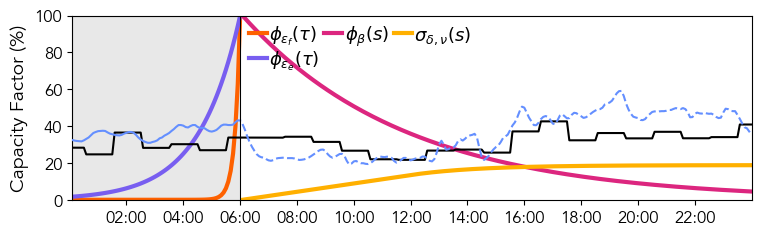

In [378]:
_fig, _ax = plt.subplots(
    figsize=(7.5, 2.25), 
    constrained_layout=True
)

plotter.plot_forecast_parameters(
    _fig, 
    _ax, 
    palette_,
    _fdu.phi_, 
    _fdu.psi_, 
    _fdu.eta_, 
    f_, 
    f_hat_, 
    e_biased_, 
    dx_, 
    dt_ = dt_ + 5, 
    interval = interval,
    n = 120,
    range_ = [0, 287],
    labels_1 = False,
    labels_2 = True,
)

_ax.legend(
    frameon = False,
    loc = (0.25, .65),
    #loc = 'lower center',
    fontsize = 13,
    columnspacing = 0.25,
    handletextpad = 0.125,
    labelspacing = 0.125,
    ncol = 3
)
#plt.savefig(IMAGES / f"hyper-{file_name}.pdf")

plt.show()

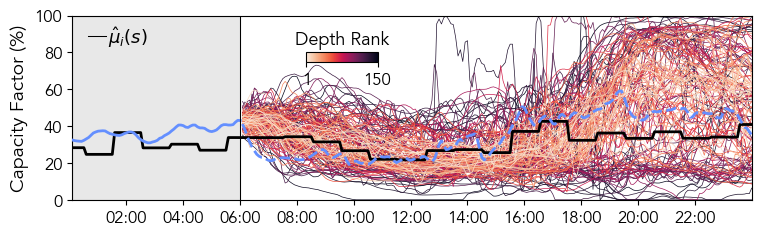

In [379]:
distance = 'MBD'
_depth = ModifiedBandDepth()

M_int_, M_int_ds_ = _fdu.functional_downsampling(
    subsample=12, 
    #n_basis=20,
    n_basis=int(1.333*(T - interval)/12),

)

depth_score_, depth_rank_ = _fdu.get_depth(_depth, M_int_)

_fig, _ax = plt.subplots(
    figsize=(7.5, 2.25), 
    constrained_layout=True
)

plotter.plot_depth(
    _fig, _ax, palette_,
    M_, f_, f_hat_, e_biased_, depth_score_, dx_, 
    dt_ = dt_ + 5, 
    interval = interval,
    n = 120,
    range_ = [0, 287],
    colorbar_pos = [500, 75, 150, 5],
    colorbar = True,
    labels_1 = True,
)

_ax.legend(
    frameon = False,
    loc = (0.0125, .775),
    #loc = 'lower center',
    fontsize = 13,
    columnspacing = 0.25,
    handletextpad = 0.125,
    labelspacing = 0.125,
    ncol = 1,
)

plt.savefig(IMAGES / f"{distance}_ranking-{file_name}.pdf")

plt.show()

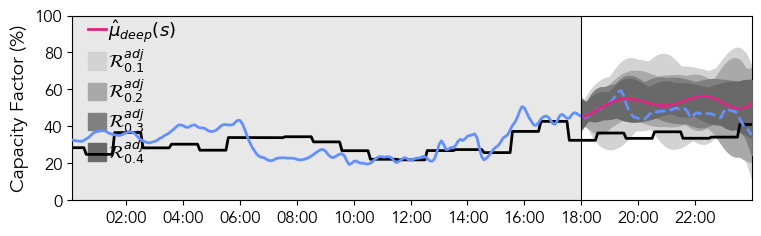

In [446]:
# Samples in each confidence band
score = 'FCS'
distance = 'MBD'
alpha_ = [0.1, 0.2, 0.3, 0.4]
_depth = ModifiedBandDepth()


M_int_, M_int_ds_ = _fdu.functional_downsampling(
    subsample=12, 
    n_basis=int(1.333*(T - interval)/12),
)

k_ = get_band_fraction(
    envelope_, 
    alpha_, 
    interval, 
    distance, 
    score
)

f_deepest_ext_, _upper, _lower = _fdu.adjusted_functional_confidence_region(
    _depth, 
    M_int_, 
    alpha_, 
    k_,
)

_fig, _ax = plt.subplots(
    figsize=(7.5, 2.25), 
    constrained_layout=True
)

plotter.plot_envelope(
    _fig, _ax, palette_,
    _upper, _lower, f_deepest_ext_, f_, f_hat_, e_biased_, dx_, 
    dt_ = dt_ + 5, 
    interval = interval,
    n = 120,
    color_med = palette_.loc[2, "ibm"],
    label = r"$\hat{\mu}_{deep} (s)$",
    CR=r"$\mathcal{{R}}^{{adj}}_{{{}}}$",
    range_ =[0, 287],
    legend_1 = False,
    legend_2 = True,
)

_ax.legend(
    frameon = False,
    loc = (0.0125, .15),
    #loc = 'lower center',
    fontsize = 13,
    columnspacing = 0.25,
    handletextpad = 0.125,
    labelspacing = 0.125,
    ncol = 1,
)

plt.savefig(IMAGES / f"{distance}_adj_regions-{file_name}.pdf")

plt.show()

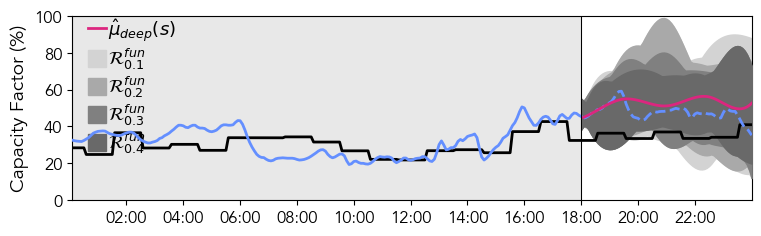

In [340]:
# Samples in each confidence band
score = 'FCS'
distance = 'MBD'
alpha_ = [0.1, 0.2, 0.3, 0.4]
_depth = ModifiedBandDepth()

M_int_, M_int_ds_ = _fdu.functional_downsampling(
    subsample=12, 
    n_basis=int(1.333*(T - interval)/12),
)

f_deepest_ext_, _upper, _lower = _fdu.functional_confidence_region(
    _depth, 
    M_int_, 
    alpha_, 
)

_fig, _ax = plt.subplots(
    figsize=(7.5, 2.25), 
    constrained_layout=True
)

plotter.plot_envelope(
    _fig, _ax, palette_,
    _upper, _lower, f_deepest_ext_, f_, f_hat_, e_biased_, dx_, 
    dt_ = dt_ + 5, 
    interval = interval,
    n = 120,
    color_med = palette_.loc[2, "ibm"],
    label = r"$\hat{\mu}_{deep} (s)$",
    CR=r"$\mathcal{{R}}^{{fun}}_{{{}}}$",
    range_ =[0, 287],
    legend_1 = False,
    legend_2 = True,
)

_ax.legend(
    frameon = False,
    loc = (0.0125, .2),
    #loc = 'lower center',
    fontsize = 13,
    columnspacing = 0.25,
    handletextpad = 0.125,
    labelspacing = 0.125,
    ncol = 1,
)

plt.savefig(IMAGES / f"{distance}_fun_regions-{file_name}.pdf")

plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


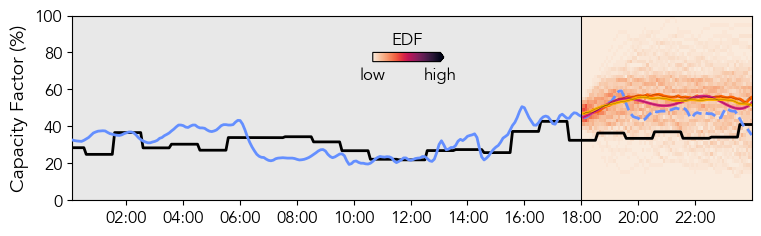

In [346]:
_fig, _ax = plt.subplots(
    figsize=(7.5, 2.25), 
    constrained_layout=True
)

plotter.plot_density_heatmap(
    _fig, 
    _ax, 
    palette_,
    M_, 
    f_wmedian_ext_, 
    f_deepest_ext_, 
    f_focal_ext_,
    f_, 
    f_hat_, 
    e_biased_, 
    dx_, 
    dt_ = dt_ + 5,
    interval = interval,
    range_ = [0, 287],
    colorbar_pos = [640, 75, 150, 5],
    colorbar = True,
    legend_1 = False,
    legend_2 = False,
)

_ax.legend(
    frameon = False,
    loc = (0.0125, .5),
    #loc = 'lower center',
    fontsize = 13,
    columnspacing = 0.25,
    handletextpad = 0.125,
    labelspacing = 0.125,
    ncol = 1,
)

plt.savefig(IMAGES / f"heatmap-{file_name}.pdf")

plt.show()

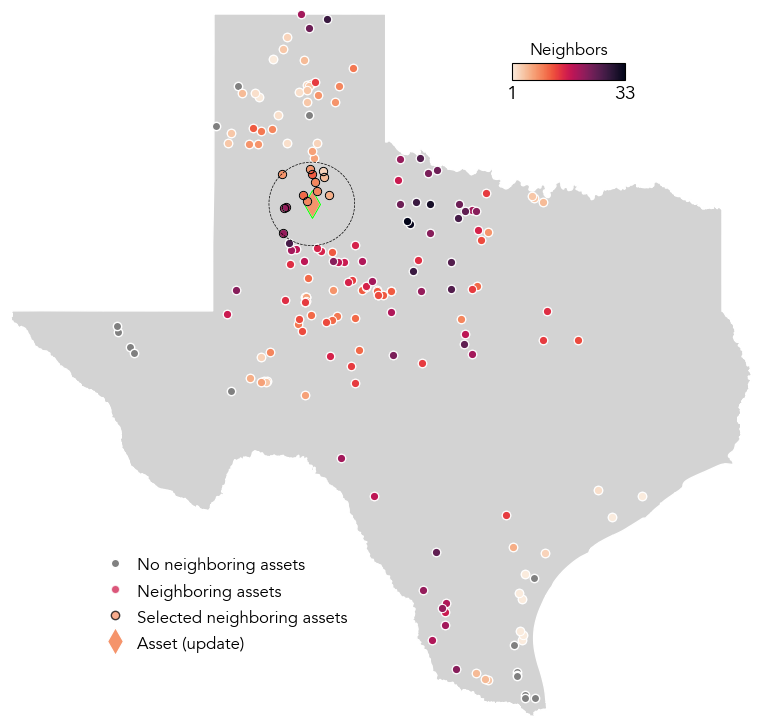

In [90]:
_fig, _ax = plt.subplots(figsize=(7.5, 7.5), constrained_layout=True)

plotter.plot_frequency_map(
    _fig, _ax, palette_, _TX, _fdu, X_tr_, X_ts_, 
    _fdu.x_, 
    _fdu.idx_fed_,
    _fdu.idx_x_, 
    _fdu.r,
)

_ax.legend(
    frameon = False, 
    bbox_to_anchor = (0.475, 0.25), 
    ncol = 1, 
    fontsize = 12
)

plt.savefig(IMAGES / f"spatial_neibors_assets-{file_name}.pdf")

plt.show()

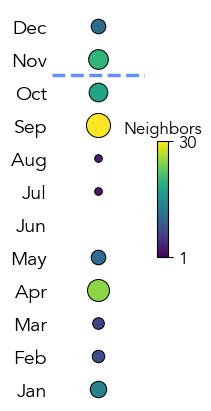

In [421]:
_fig, _ax = plt.subplots(figsize=(2, 4), constrained_layout=True)

plotter.scenarios_frequency_dates(
    _fig, 
    _ax, 
    palette_,
    _fdu.idx_fed_, 
    _fdu.idx_x_,
    T_tr_[:, interval], 
    _fdu.date,
    scale = 10,
    colorbar = True,
)

plt.savefig(IMAGES / f"temporal_neibors-{file_name}.pdf")

plt.show()

(150,) (67881,) (150,) (150,)


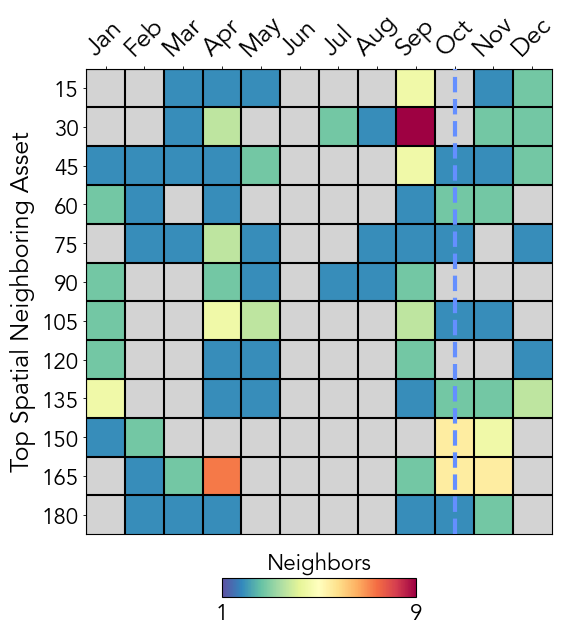

In [380]:
_fig, _ax = plt.subplots(figsize=(7.5, 6.25), constrained_layout=True)

plotter.selected_scenarios_heatmap(
    _fig, 
    _ax, 
    palette_,
    _fdu._haversine_dist, 
    _fdu.idx_fed_, 
    _fdu.idx_x_local_,
    _fdu.d_x_,
    _fdu.x_, 
    T_tr_[:, interval], 
    X_ts_,
    _fdu.date,
    colorbar = True,
)

plt.savefig(IMAGES / f"spatiotemporal_heatmap-{file_name}.pdf")

plt.show()

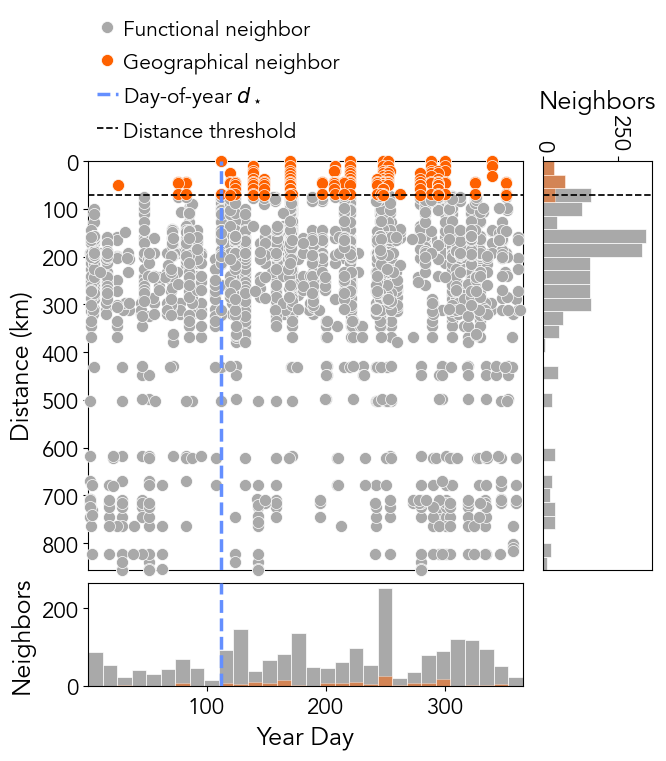

In [93]:
_fig, _ax = plt.subplot_mosaic(
    [["A", "B"], ["C", "."]],
    figsize=(6.5, 7.5),
    layout="constrained",
    gridspec_kw=dict(width_ratios=(1, 0.25), height_ratios=(1, 0.25)),
)

plotter.plot_filtered_scenarios(
    _fig, 
    _ax["A"], 
    palette_,
    _fdu.idx_fed_, 
    _fdu.idx_x_, 
    _fdu.idx_x_local_, 
    _fdu.d_x_,
    t_tr_, 
    t_ts_[day], 
    _fdu.r,
)

plotter.plot_distance_histogram(
    _fig, 
    _ax["B"], 
    palette_,
    _fdu.idx_fed_, 
    _fdu.idx_x_local_, 
    _fdu.d_x_, 
    _fdu.r,
)

plotter.plot_dates_histogram(
    _fig, 
    _ax["C"], 
    palette_,
    _fdu.idx_fed_, 
    _fdu.idx_x_local_, 
    _fdu.d_x_,
    t_tr_, 
    t_ts_[day], 
)

_ax["A"].legend(
    frameon = False,
    ncol = 1,
    columnspacing = 0.625,
    handletextpad = 0.25,
    loc = (0.0, 1.025),
    fontsize = 15,
)

plt.savefig(IMAGES / f"spatiotemporal_neighbors-{file_name}.pdf")

plt.show()

0.5893596192323725


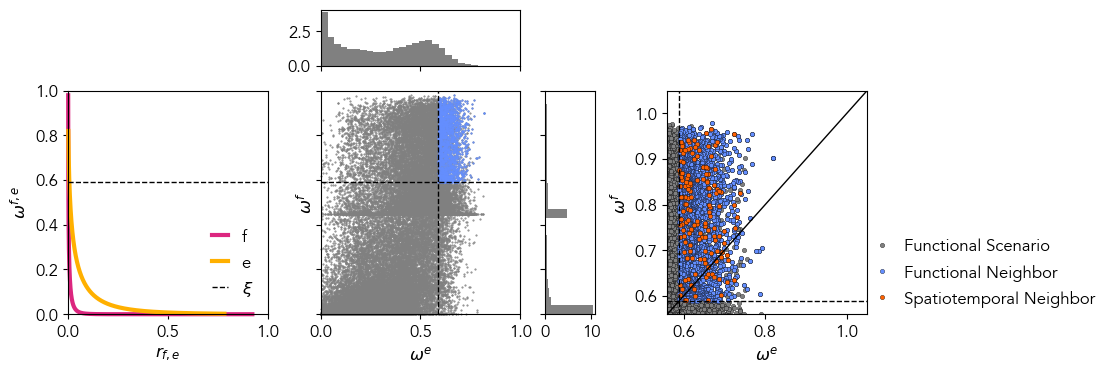

In [61]:
_fig, _ax = plt.subplot_mosaic(
    [[".", ".", "e", ".", ".", "."],
     ["A", "A", "B", "f", "C", "C"],
     ["A", "A", "B", "f", "C", "C"],],
    figsize=(11, 3.625),
    layout="constrained",
    gridspec_kw=dict(width_ratios=(2, 2, 4, 1, 2, 2), height_ratios=(1, 2, 2)),
)

plotter.plot_density_threshold(
    _fig, 
    _ax["A"], 
    palette_, 
    _fdu.d_f_, 
    _fdu.d_e_, 
    _fdu.w_f_, 
    _fdu.w_e_, 
    _fdu.xi,
    label1 = 'f',
    label2 = 'e',
    ylabel = r"$\omega^{f,e}$",
    xlabel = r"$r_{f,e}$",
)

plotter.plot_functional_neighborhood(
    _fig, 
    _ax["B"], 
    _ax["e"], 
    _ax["f"], 
    palette_, 
    _fdu.idx_fed_, 
    _fdu.w_e_, 
    _fdu.w_f_, 
    _fdu.xi,
    xlabel = r"$\omega^{e}$",
    ylabel = r"$\omega^{f}$",
)

plotter.plot_selected_functional_neighbors(
    _fig, 
    _ax["C"], 
    palette_,
    _fdu.idx_fed_, 
    _fdu.idx_x_local_, 
    _fdu.w_e_, 
    _fdu.w_f_, 
    _fdu.xi,
    xlabel = r"$\omega^{e}$",
    ylabel = r"$\omega^{f}$",
)

_ax["C"].legend(
    frameon = False, 
    fontsize = 12, 
    ncol = 1, 
    loc = (1.0, 0.0)
)

plt.savefig(IMAGES / f"fneighbor_fe-{file_name}.pdf")

plt.show()

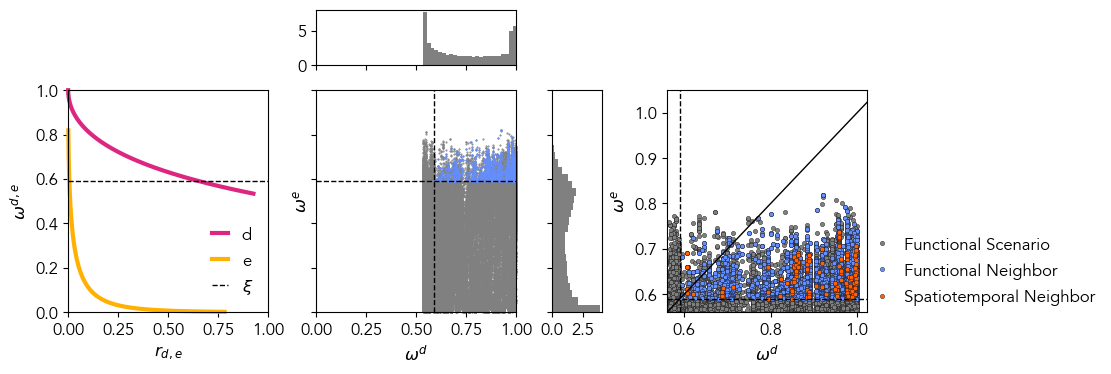

In [62]:
_fig, _ax = plt.subplot_mosaic(
    [[".", ".", "e", ".", ".", "."],
     ["A", "A", "B", "f", "C", "C"],
     ["A", "A", "B", "f", "C", "C"],],
    figsize=(11, 3.625),
    layout="constrained",
    gridspec_kw=dict(width_ratios=(2, 2, 4, 1, 2, 2), height_ratios=(1, 2, 2)),
)

plotter.plot_density_threshold(
    _fig, 
    _ax["A"], 
    palette_, 
    _fdu.d_d_, 
    _fdu.d_e_, 
    _fdu.w_d_, 
    _fdu.w_e_, 
    _fdu.xi,
    label1 = 'd',
    label2 = 'e',
    ylabel = r"$\omega^{d,e}$",
    xlabel = r"$r_{d,e}$",
)

plotter.plot_functional_neighborhood(
    _fig, 
    _ax["B"], 
    _ax["e"], 
    _ax["f"], 
    palette_, 
    _fdu.idx_fed_, 
    _fdu.w_d_, 
    _fdu.w_e_, 
    _fdu.xi,
    xlabel = r"$\omega^{d}$",
    ylabel = r"$\omega^{e}$",
)

plotter.plot_selected_functional_neighbors(
    _fig, 
    _ax["C"], 
    palette_,
    _fdu.idx_fed_, 
    _fdu.idx_x_local_, 
    _fdu.w_d_, 
    _fdu.w_e_, 
    _fdu.xi,
    xlabel = r"$\omega^{d}$",
    ylabel = r"$\omega^{e}$",
)

_ax["C"].legend(
    frameon = False, 
    fontsize = 12, 
    ncol = 1, 
    loc = (1.0, 0.0)
)

plt.savefig(IMAGES / f"fneighbor_ed-{file_name}.pdf")

plt.show()

13117.343513870048


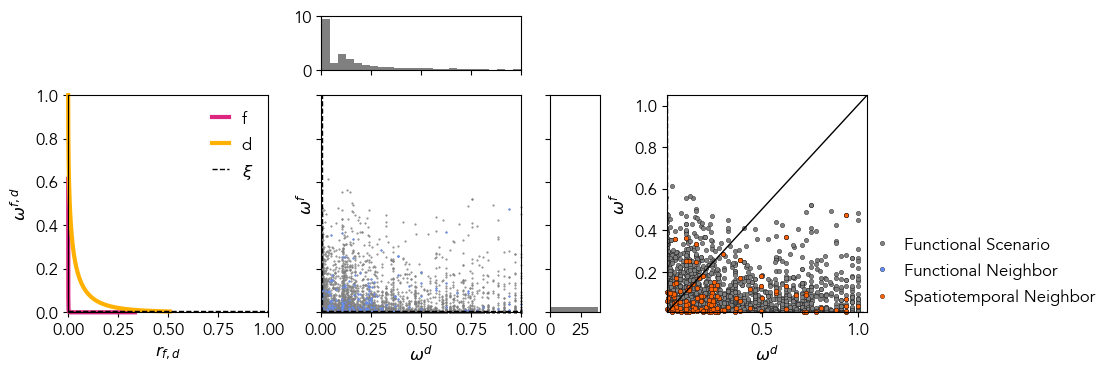

In [19]:
_fig, _ax = plt.subplot_mosaic(
    [[".", ".", "e", ".", ".", "."],
     ["A", "A", "B", "f", "C", "C"],
     ["A", "A", "B", "f", "C", "C"],],
    figsize=(11, 3.625),
    layout="constrained",
    gridspec_kw=dict(width_ratios=(2, 2, 4, 1, 2, 2), height_ratios=(1, 2, 2)),
)

plotter.plot_density_threshold(
    _fig, 
    _ax["A"], 
    palette_, 
    _fdu.d_f_, 
    _fdu.d_d_, 
    _fdu.w_f_, 
    _fdu.w_d_, 
    _fdu.xi,
    label1 = 'f',
    label2 = 'd',
    ylabel = r"$\omega^{f,d}$",
    xlabel = r"$r_{f,d}$",
)
plotter.plot_functional_neighborhood(
    _fig, 
    _ax["B"], 
    _ax["e"], 
    _ax["f"], 
    palette_, 
    _fdu.idx_fed_, 
    _fdu.w_d_, 
    _fdu.w_f_, 
    _fdu.xi,
    xlabel = r"$\omega^{d}$",
    ylabel = r"$\omega^{f}$",
)
print(_fdu.w_d_.sum())
plotter.plot_selected_functional_neighbors(
    _fig, 
    _ax["C"], 
    palette_,
    _fdu.idx_fed_, 
    _fdu.idx_x_local_, 
    _fdu.w_d_, 
    _fdu.w_f_, 
    _fdu.xi,
    xlabel = r"$\omega^{d}$",
    ylabel = r"$\omega^{f}$",
)

_ax["C"].legend(
    frameon = False, 
    fontsize = 12, 
    ncol = 1, 
    loc = (1.0, 0.0)
)

plt.savefig(IMAGES / f"fneighbor_df-{file_name}.pdf")

plt.show()

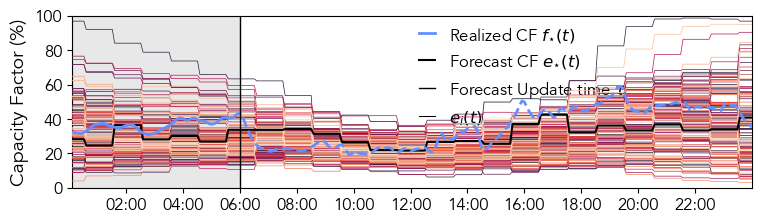

In [20]:
_fig, _ax = plt.subplots(figsize=(7.5, 2.125), constrained_layout=True)

plotter.plot_forecasts(
    _fig, 
    _ax, 
    palette_, 
    E_tr_biased_, 
    _fdu.w_fed_, 
    _fdu.idx_x_, 
    f_, 
    f_hat_, 
    e_biased_, 
    dx_, 
    dt_ = dt_ + 5, 
    interval = interval,
    range_ = [0, 287],
    n = 120,
    legend_1 = True,
    legend_2 = True,
)

_ax.legend(
    frameon = False,
    loc = (0.25, .65),
    #loc = 'lower center',
    fontsize = 13,
    columnspacing = 0.25,
    handletextpad = 0.125,
    labelspacing = 0.125,
    ncol = 3
)

#plt.savefig(IMAGES / f"dayahead_neighbors-{file_name}.pdf")

plt.show()

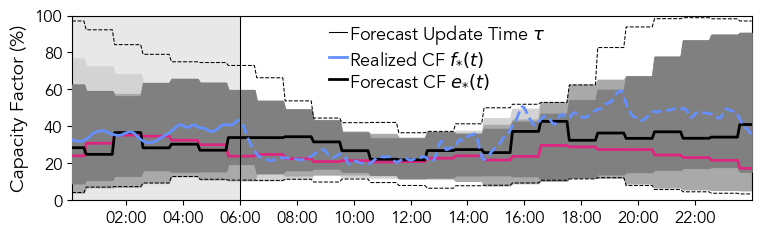

In [419]:
# Calculate confidence intervals from Directional Quantiles
f_deepest_ext_, _upper, _lower = _fdu.functional_boxplot(
    E_tr_biased_[_fdu.idx_x_, :], 
    depth_score_
)

_fig, _ax = plt.subplots(
    figsize=(7.5, 2.25), 
    constrained_layout=True
)

plotter.plot_enhanced_functional_boxplot(
    _fig, _ax, palette_,
    _upper, _lower, f_deepest_ext_, f_, f_hat_, e_biased_, dx_,
    dt_ = dt_ + 5, 
    interval = interval,
    CR=r"$\mathcal{{R}}^{{bxp}}_{{\alpha={}}}$",
    n = 120,
    range_ = [0, 287],
    legend_1 = True,
    legend_2 = False,
)

_ax.legend(
    frameon = False,
    loc = (0.3675, .55),
    #loc = 'lower center',
    fontsize = 13,
    columnspacing = 0.25,
    handletextpad = 0.125,
    labelspacing = 0.125,
    ncol = 1,
)

plt.savefig(IMAGES / f"{distance}_box_forecast-{file_name}.pdf")

plt.show()

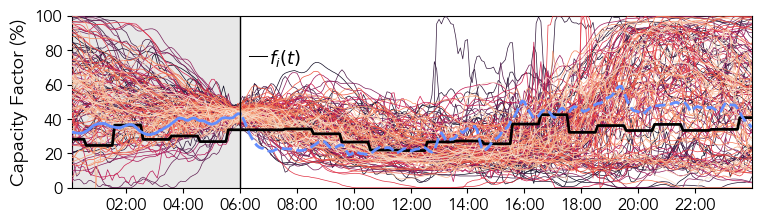

In [393]:
_fig, _ax = plt.subplots(figsize=(7.5, 2.125), constrained_layout=True)

plotter.plot_neighbors(
    _fig, 
    _ax, 
    palette_, 
    F_tr_, 
    _fdu.w_fed_, 
    _fdu.idx_x_, 
    f_, 
    f_hat_, 
    e_biased_, 
    dx_, 
    dt_ = dt_ + 5, 
    interval = interval,
    n = 120,
    range_ = [0, 287],
    legend_1 = True,
    legend_2 = False,
)

_ax.legend(
    frameon = False,
    loc = (0.25, .65),
    #loc = 'lower center',
    fontsize = 13,
    columnspacing = 0.25,
    handletextpad = 0.125,
    labelspacing = 0.125,
    ncol = 3
)
#plt.savefig(IMAGES / f"partial_neighbors-{file_name}.pdf")

plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


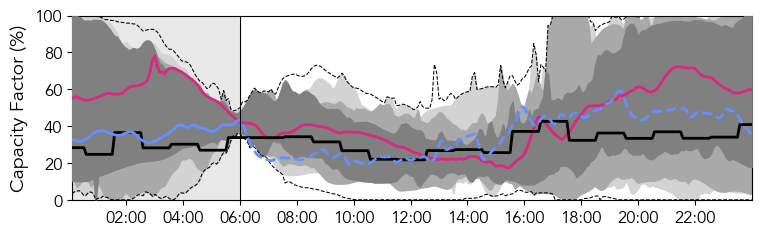

In [406]:
# Calculate confidence intervals from Directional Quantiles
f_deepest_ext_, _upper, _lower = _fdu.functional_boxplot(
    F_tr_[_fdu.idx_x_, :], 
    depth_score_
)

_fig, _ax = plt.subplots(
    figsize=(7.5, 2.25), 
    constrained_layout=True
)

plotter.plot_enhanced_functional_boxplot(
    _fig, _ax, palette_,
    _upper, _lower, f_deepest_ext_, f_, f_hat_, e_biased_, dx_,
    dt_ = dt_ + 5, 
    interval = interval,
    CR=r"$\mathcal{{R}}^{{bxp}}_{{\alpha={}}}$",
    n = 120,
    range_ = [0, 287],
    legend_1 = False,
    legend_2 = False,
)

_ax.legend(
    frameon = False,
    loc = (0.25, .625),
    #loc = 'lower center',
    fontsize = 13,
    columnspacing = 0.25,
    handletextpad = 0.125,
    labelspacing = 0.125,
    ncol = 3,
)

plt.savefig(IMAGES / f"{distance}_box_realized-{file_name}.pdf")

plt.show()

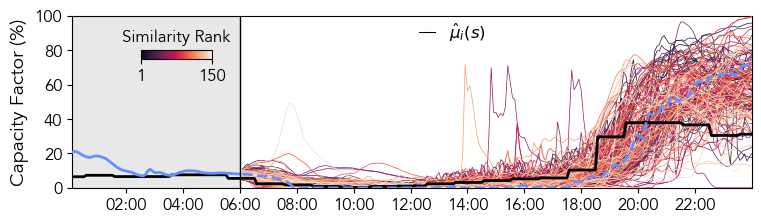

In [625]:
_fig, _ax = plt.subplots(figsize=(7.5, 2.125), constrained_layout=True)

plotter.plot_updates(
    _fig, 
    _ax, 
    palette_, 
    M_, 
    f_, 
    f_hat_, 
    e_biased_, 
    _fdu.w_fed_, 
    _fdu.idx_x_, 
    dx_, 
    dt_ = dt_ + 5, 
    interval = interval,
    n = 120,
    range_ = [0, 287],
    legend_1=True,
    legend_2=False,
    colorbar=True,
    colorbar_pos = [150, 75, 150, 5],
)

_ax.legend(
    frameon = False,
    loc = (0.25, .65),
    #loc = 'lower center',
    fontsize = 13,
    columnspacing = 0.25,
    handletextpad = 0.125,
    labelspacing = 0.125,
    ncol = 3
)

plt.savefig(IMAGES / f"dynamic_update_neighbors-{file_name}.pdf")

plt.show()

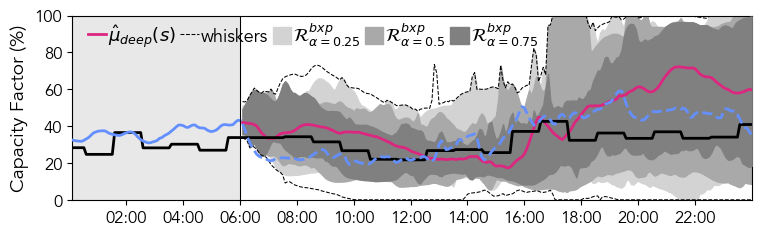

In [420]:
# Calculate confidence intervals from Directional Quantiles
f_deepest_ext_, _upper, _lower = _fdu.functional_boxplot(
    M_, 
    depth_score_
)

_fig, _ax = plt.subplots(
    figsize=(7.5, 2.25), 
    constrained_layout=True
)

plotter.plot_enhanced_functional_boxplot(
    _fig, _ax, palette_,
    _upper, _lower, f_deepest_ext_, f_, f_hat_, e_biased_, dx_,
    dt_ = dt_ + 5, 
    interval = interval,
    CR=r"$\mathcal{{R}}^{{bxp}}_{{\alpha={}}}$",
    n = 120,
    range_ = [0, 287],
    legend_1 = False,
    legend_2 = True,
)

_ax.legend(
    frameon = False,
    loc = (0.0125, .775),
    #loc = 'lower center',
    fontsize = 13,
    columnspacing = 0.25,
    handletextpad = 0.125,
    labelspacing = 0.125,
    ncol = 5,
)

plt.savefig(IMAGES / f"{distance}_box_fused-{file_name}.pdf")

plt.show()

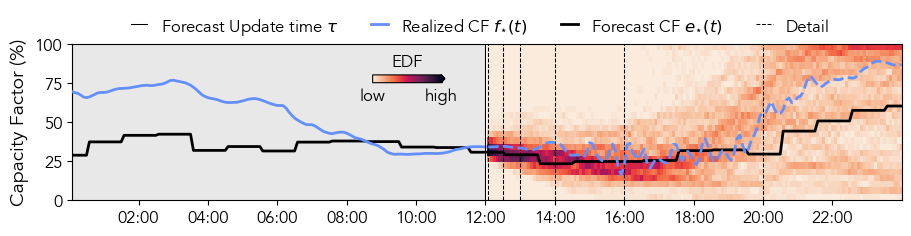

In [81]:
slices_ = [6, 12, 24, 48, 96]

_fig, _ax = plt.subplots(
    figsize=(9, 2.25), 
    constrained_layout=True
)

plotter.plot_heatmap_slices(
    _fig, 
    _ax, 
    palette_, 
    _fdu.M_, 
    f_, 
    f_hat_, 
    e_biased_, 
    dx_, 
    dt_ = dt_ + 5, 
    interval = interval,
    slices_ = slices_,
    range_ = [0, 287],
    n = 120,
    colorbar = True,
)

_ax.legend(
    loc = (0.0625, 1), 
    frameon = False, 
    fontsize = 12, 
    ncol = 4
)

plt.savefig(IMAGES / f"heatmap_detail-{file_name}.pdf")

plt.show()

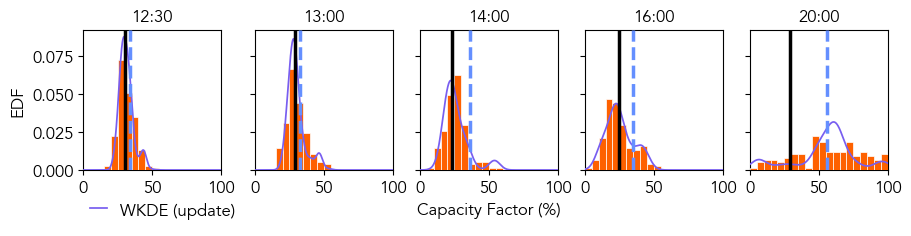

In [86]:
WKDs_ = _fdu.weighted_kernel_density_estimation(
    100*M_, 
    weights = _fdu.w_fed_[_fdu.idx_x_local_],
    algorithm = "auto", 
    kernel = "gaussian",
)

KDs_ = _fdu.kernel_density_estimation(
    100*M_, 
    algorithm = "auto", 
    kernel = "gaussian",
)

_fig, _ax = plt.subplots(
    1, len(slices_), 
    figsize = (9, 2.25), 
    sharey = True, 
    layout = "constrained"
)

plotter.plot_histogram_cuts(
    _fig, 
    _ax, 
    palette_, 
    WKDs_, 
    M_, 
    f_, 
    f_hat_, 
    e_biased_, 
    dx_, 
    dt_, 
    interval, 
    slices_)

_ax[0].legend(
    frameon = False, 
    fontsize = 12, 
    loc = (0, -.4)
)

plt.savefig(IMAGES / f"marginal_detail-{file_name}.pdf")

plt.show()

In [238]:
F_curves_ = []
M_curves_ = []
D_curves_ = []
for interval in range(6, 282, 6):

    M_ = _fdu.predict(
        F_ts_[day, :interval, asset],
        E_ts_lin_[day, :, asset],
        X_ts_[asset, :],
        t_ts_[day],
        forget_rate_f = get_hyper(hyper_, "forget_rate_f", interval),
        forget_rate_e = get_hyper(hyper_, "forget_rate_e", interval),
        lookahead_rate = get_hyper(hyper_, "lookahead_rate", interval),
        length_scale_f = get_hyper(hyper_, "length_scale_f", interval),
        length_scale_e = get_hyper(hyper_, "length_scale_e", interval),
        length_scale_d = get_hyper(hyper_, "length_scale_d", interval),
        sigma = get_hyper(hyper_, "sigma", interval),
        nu = get_hyper(hyper_, "nu", interval),
        kappa_0 = get_hyper(hyper_, "kappa_0", interval),
        kappa = get_hyper(hyper_, "kappa", interval),
        p_fusion = get_hyper(hyper_, "p_fusion", interval),
    )

    # Compute depth to find the focal curve
    _F = FDataGrid(data_matrix=_fdu.M_, grid_points=_fdu.dt_[interval:])

    depth_rank_ = np.argsort(_depth(_F))[::-1]

    M_curves_.append(np.median(_fdu.M_, axis=0))
    F_curves_.append(_fdu.f_focal_)
    D_curves_.append(_fdu.M_[depth_rank_[0], :])

print(len(F_curves_), len(M_curves_), len(D_curves_))

46 46 46


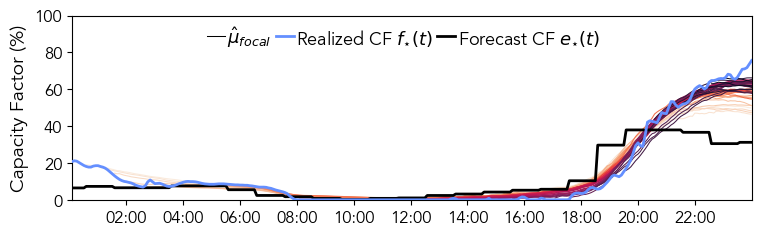

In [247]:
_fig, _ax = plt.subplots(
    figsize=(7.5, 2.25), 
    constrained_layout=True
)

plotter.plot_dynamic_update(
    _fig, _ax, palette_, 
    F_curves_, f_, f_hat_, e_biased_, dx_, dt_ + 5,
    label = r"$\hat{\mu}_{focal}$",
    range_ = [0, 287],
    legend = True,
    colorbar = False,
)

_ax.legend(
    frameon = False,
    loc = (0.1875, .775),
    #loc = 'lower center',
    fontsize = 13,
    columnspacing = 0.25,
    handletextpad = 0.125,
    labelspacing = 0.125,
    ncol = 3,
)

plt.savefig(IMAGES / f"dynamic_update-focal_curve-{file_name}.pdf")

plt.show()

# _fig, _ax = plt.subplots(figsize=(7.5, 2.125), constrained_layout=True)

# plotter.plot_dynamic_update(
#     _fig, _ax, palette_, 
#     M_curves_, f_, f_hat_, e_biased_, dx_, dt_ + 5, 
#     range_ = [0, 287],
#     legend = False,
#     colorbar = False,
#     label = r"$\hat{\mu}_{med}$"
# )

# _ax.legend(
#     #loc = (0.25, -0.1), 
#     frameon = False, 
#     fontsize = 12, 
#     ncol = 3,
# )

# plt.savefig(IMAGES / f"dynamic_update-median_curve-{file_name}.pdf")

# plt.show()

# _fig, _ax = plt.subplots(figsize=(7.5, 2.125), constrained_layout=True)

# plotter.plot_dynamic_update(
#     _fig, _ax, palette_, 
#     D_curves_, f_, f_hat_, e_biased_, dx_, dt_ + 5, 
#     range_ = [0, 287],
#     legend = True,
#     colorbar = False,
#     label = r"$\hat{\mu}_{deep}$"
# )

# _ax.legend(
#     loc = (0.25, 0.0), 
#     frameon = False, 
#     fontsize = 12, 
#     ncol = 3
# )

# plt.savefig(IMAGES / f"dynamic_update-deepest_curve-{file_name}.pdf")

# plt.show()

(67881,) (171,) (2166, 2) (171, 2)


 /Users/Guille/opt/anaconda3/envs/py38/lib/python3.8/site-packages/cartopy/mpl/gridliner.py:844: ShapelyDeprecationWarning:__len__ for multi-part geometries is deprecated and will be removed in Shapely 2.0. Check the length of the `geoms` property instead to get the  number of parts of a multi-part geometry.
 /Users/Guille/opt/anaconda3/envs/py38/lib/python3.8/site-packages/cartopy/mpl/gridliner.py:855: ShapelyDeprecationWarning:Iteration over multi-part geometries is deprecated and will be removed in Shapely 2.0. Use the `geoms` property to access the constituent parts of a multi-part geometry.
 /Users/Guille/opt/anaconda3/envs/py38/lib/python3.8/site-packages/cartopy/mpl/gridliner.py:850: ShapelyDeprecationWarning:__getitem__ for multi-part geometries is deprecated and will be removed in Shapely 2.0. Use the `geoms` property to access the constituent parts of a multi-part geometry.
 <__array_function__ internals>:5: ShapelyDeprecationWarning:The array interface is deprecated and will

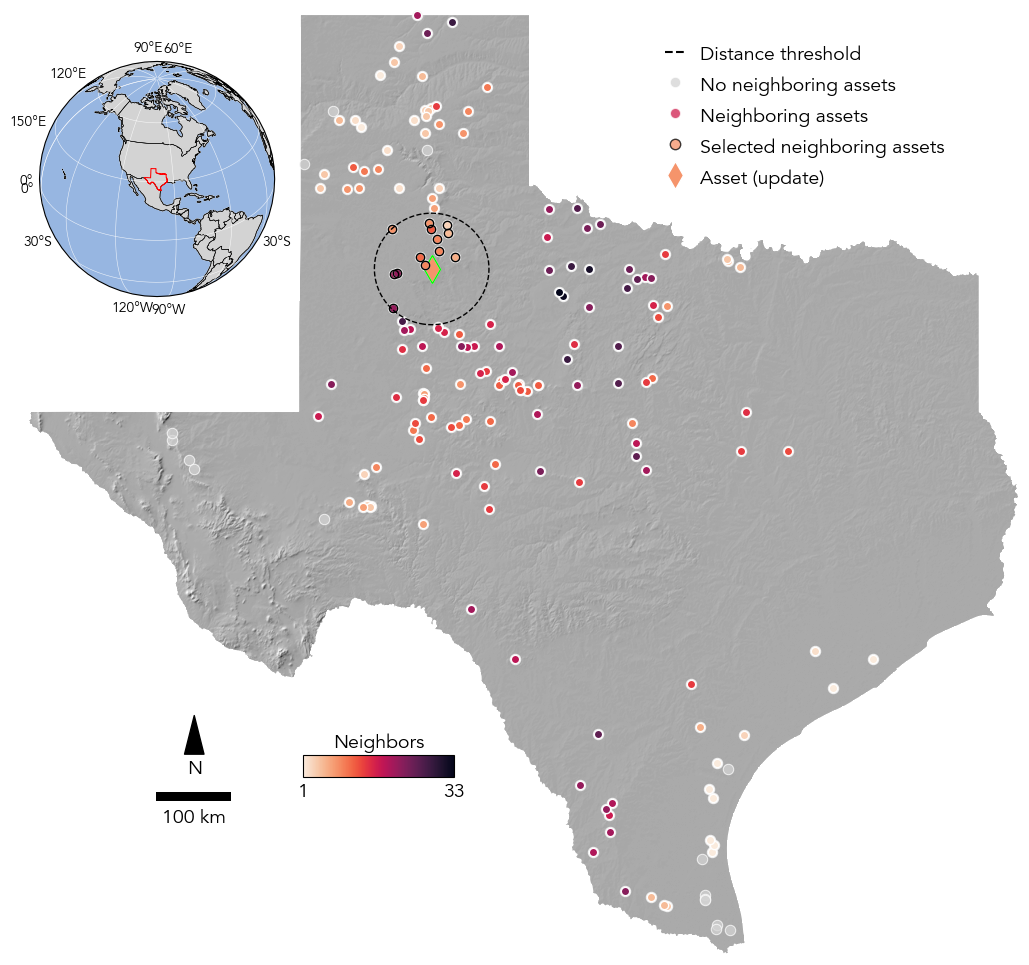

In [92]:
_fig, _ax = plt.subplots(1, 1, figsize=(10, 10), layout="constrained")

# Add an inset globe showing Texas
plotter.globe_inset(
    _fig, _ax, _TX, 
    x0 = 0.005, 
    y0 = 0.7, 
    width = 0.25, 
    height = 0.25
)

_fig, _ax = plotter.hillshade(_fig, _ax, _TX)

plotter.plot_hillshade_frequency_map(
    _fig, _ax, palette_, _TX, _fdu, X_tr_, X_ts_, 
    _fdu.x_, 
    _fdu.idx_fed_,
    _fdu.idx_x_, 
    _fdu.r,
)

# Add compass (North arrow)
x = 0.1675
y = 0.2575
arrow_length = 0.06  # relative axes coords

_ax.annotate(
    "N",
    xy = (x, y),
    xytext = (x, y - arrow_length),
    arrowprops = dict(facecolor = "k", 
                      arrowstyle = "wedge,tail_width=1,shrink_factor=.5"),
    ha = "center",
    va = "center",
    fontsize = 14,
    xycoords = _ax.transAxes,
)

scalebar = ScaleBar(
    dx = 100,  # scaling factor
    units = "km",
    dimension = "si-length",  # could also be 'imperial-length.'
    location = "lower left",
    length_fraction = 0.09,  # fraction of the axis for bar length
    color = "black",
    box_color = "None",
    box_alpha = 1.0,
    border_pad = 9,
    font_properties = {"size": 14},
)

_ax.add_artist(scalebar)

_ax.legend(
    frameon = False, 
    bbox_to_anchor = (0.625, 0.9875), 
    ncol = 1, 
    fontsize = 14
)

plt.savefig(IMAGES / f"geographical_neighbors-{file_name}.pdf")

plt.show()

(3600, 216)
72 (3600, 216) 36 72
-0.11296296296296326 0.20254629629629628
[ 0.2025463  -0.08009259 -0.11296296 -0.05856481 -0.04182099 -0.05532407
  0.00902778 -0.02492284  0.02361111  0.13850309]


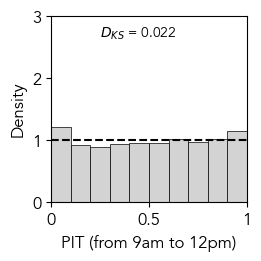

In [375]:
interval = 72

pit_ = loader.pit(
    _init, 
    resource, 
    method, 
    aggregation, 
    interval, 
    exp_description="unbiased-025-6",
    path_to_validation=VALIDATION
)

print(pit_.shape)

_fig, _ax = plt.subplots(
    figsize = (2.5, 2.5), 
    constrained_layout = True
)

INTERVAL = 36
LEAD = 36
print(interval, pit_.shape, INTERVAL, (INTERVAL + LEAD))

plotter.plot_pit(
    _fig, _ax, pit_[:, INTERVAL:(INTERVAL + LEAD)].flatten(), 
    v = 0.4,
    bins = 10,
    xlabel = 'PIT (from 9am to 12pm)'
)

plt.savefig(
    IMAGES / f"PIT-{resource}-{INTERVAL}-{LEAD}-{interval}.pdf"
)
plt.show()